In [1]:
import numpy as np
from scipy import integrate, optimize
import matplotlib.pyplot as plt

https://stackoverflow.com/questions/79508027/graphing-nonlinear-systems-of-odes-in-python

In [2]:
K = 17.3
epsilon = 4.9
r = 2.7
mu = 0.9
gamma = 3.2  
alpha = 4 / (K - epsilon) ** 2
alpha

0.02601456815816857

In [3]:
p0 = (alpha, r, K, epsilon, mu, gamma)
p0

(0.02601456815816857, 2.7, 17.3, 4.9, 0.9, 3.2)

In [4]:
def model(t, y, alpha, r, K, epsilon, mu, gamma):
    return np.array([
        gamma * y[1] / (1 + y[1]) - mu * y[0],
        alpha * r * (y[1] ** 2 / (y[1] + y[0])) * (K - y[1]) * (y[1] - epsilon) - mu * y[1]
    ])

$$
\begin{align}
\frac{\mathrm{d}M}{\mathrm{d}t} &= \frac{\gamma N}{1 + N} - \mu M \\
\frac{\mathrm{d}N}{\mathrm{d}t} &= \alpha r \frac{N^2}{M + N} (K- N) (N - \epsilon) - \mu N
\end{align}
$$

In [5]:
Mlin = np.linspace(-5, 15, 500)
Nlin = np.linspace(-5, 5, 500)
M, N = np.meshgrid(Mlin, Nlin)

In [6]:
t = np.linspace(2, 10, 200)

In [7]:
U, V = model(t, [M, N], *p0)
C = np.sqrt(U ** 2 + V ** 2)

/tmp/ipykernel_1461/4181885818.py:4: RuntimeWarning: divide by zero encountered in divide
  alpha * r * (y[1] ** 2 / (y[1] + y[0])) * (K - y[1]) * (y[1] - epsilon) - mu * y[1]


In [8]:
def proxy(x, *args):
    return model(None, x, *args)

In [10]:
sol0 = optimize.root(proxy, x0=[1, 1], args=p0)
sol1 = optimize.root(proxy, x0=[5, 7.5], args=p0)
sol2 = optimize.root(proxy, x0=[2.5, 17.5], args=p0)
sol3 = optimize.root(proxy, x0=[13.6564215102769, -1.35200502328156], args=p0)

/tmp/ipykernel_1461/4181885818.py:4: RuntimeWarning: invalid value encountered in scalar divide
  alpha * r * (y[1] ** 2 / (y[1] + y[0])) * (K - y[1]) * (y[1] - epsilon) - mu * y[1]


In [11]:
sol3

 message: The solution converged.
 success: True
  status: 1
     fun: [ 3.553e-15  2.220e-16]
       x: [ 1.366e+01 -1.352e+00]
  method: hybr
    nfev: 6
    fjac: [[-9.940e-01  1.092e-01]
           [-1.092e-01 -9.940e-01]]
       r: [ 9.054e-01 -2.553e+01 -4.072e+00]
     qtf: [ 1.199e-13  1.496e-14]

In [12]:
M0 = 5.6667
N0 = K / 1.5

In [13]:
y0 = (M0, N0)
y1 = (4, 6)
y2 = (10, 2.5)

In [14]:
ivp0 = integrate.solve_ivp(model, [t.min(), t.max()], args=p0, y0=y0, t_eval=t)
ivp1 = integrate.solve_ivp(model, [t.min(), t.max()], args=p0, y0=y1, t_eval=t)
ivp2 = integrate.solve_ivp(model, [t.min(), t.max()], args=p0, y0=y2, t_eval=t)

In [15]:
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

(15.8, 16.0)

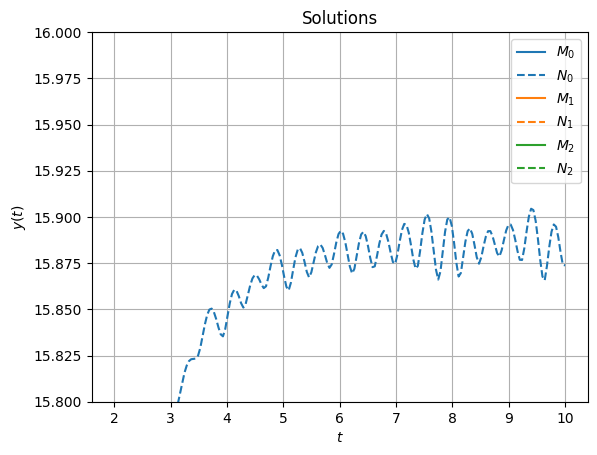

In [16]:
fig, axe = plt.subplots()
for ivp, color in zip([ivp0, ivp1, ivp2], colors[:3]):
    axe.plot(t, ivp.y[0], "-", color=color)
    axe.plot(t, ivp.y[1], "--", color=color)
axe.grid()
axe.set_title("Solutions")
axe.set_xlabel("$t$")
axe.set_ylabel("$y(t)$")
axe.legend(["$M_0$", "$N_0$", "$M_1$", "$N_1$", "$M_2$", "$N_2$"])
axe.set_ylim([15.8, 16])
#axe.set_ylim([-0.1, 0.1])
#axe.set_ylim([3.3, 3.4])

Text(0.5, 1.0, 'Phase diagram')

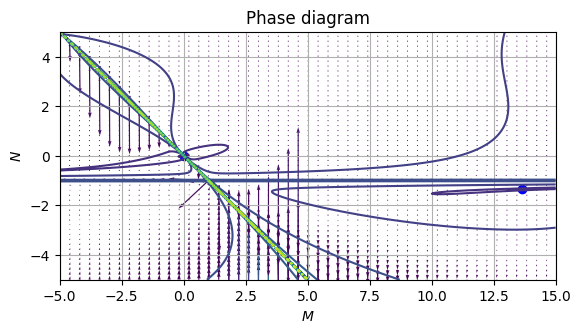

In [26]:
fig, axe = plt.subplots()
axe.quiver(M[::10,::10], N[::10,::10], U[::10,::10], V[::10,::10], C[::10,::10])
axe.contour(M, N, np.log10(C), 20, cmap="viridis")
for sol in [sol0, sol3]:
    axe.scatter(*sol.x, color="blue")
#for y, ivp, color in zip([y0, y1, y2], [ivp0, ivp1, ivp2], colors[:3]):
#    axe.scatter(*y, color=color)
#    axe.plot(*ivp.y, color=color)
axe.grid()
axe.set_aspect("equal")
axe.set_xlabel("$M$")
axe.set_ylabel("$N$")
axe.set_title("Phase diagram")

Text(0.5, 1.0, 'Phase diagram')

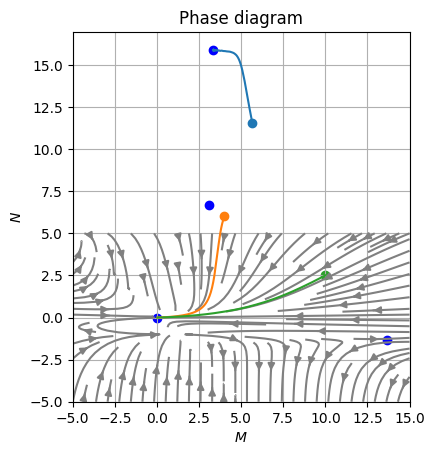

In [24]:
fig, axe = plt.subplots()
axe.streamplot(M, N, U, V, color="grey")
for sol in [sol0, sol1, sol2, sol3]:
    axe.scatter(*sol.x, marker="o", color="blue")
for y, ivp, color in zip([y0, y1, y2], [ivp0, ivp1, ivp2], colors[:3]):
    axe.scatter(*y, color=color)
    axe.plot(*ivp.y, color=color)
axe.grid()
axe.set_aspect("equal")
axe.set_xlabel("$M$")
axe.set_ylabel("$N$")
axe.set_title("Phase diagram")

Text(0.5, 1.0, 'Phase diagram')

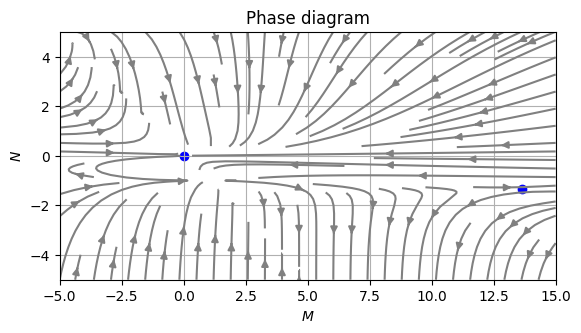

In [25]:
fig, axe = plt.subplots()
axe.streamplot(M, N, U, V, color="grey")
for sol in [sol0, sol3]:
    axe.scatter(*sol.x, marker="o", color="blue")
axe.grid()
axe.set_aspect("equal")
axe.set_xlabel("$M$")
axe.set_ylabel("$N$")
axe.set_title("Phase diagram")

(15.8, 16.0)

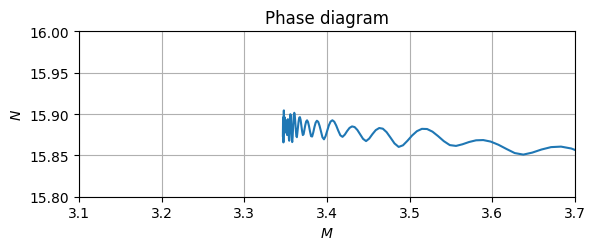

In [19]:
fig, axe = plt.subplots()
axe.streamplot(M, N, U, V, color="grey")
axe.plot(*ivp0.y)
#axe.contour(M, N, np.log10(C), 20, cmap="viridis")
axe.grid()
axe.set_aspect("equal")
axe.set_xlabel("$M$")
axe.set_ylabel("$N$")
axe.set_title("Phase diagram")
axe.set_xlim([3.1, 3.7])
axe.set_ylim([15.8, 16])

In [20]:
sol0

 message: The iteration is not making good progress, as measured by the 
            improvement from the last ten iterations.
 success: False
  status: 5
     fun: [-4.941e-324 -4.941e-324]
       x: [ 1.976e-323  4.941e-324]
  method: hybr
    nfev: 82
    fjac: [[-1.000e+00  0.000e+00]
           [ 0.000e+00 -1.000e+00]]
       r: [ 9.000e-01 -3.200e+00  6.854e+00]
     qtf: [ 4.941e-324  4.941e-324]

In [21]:
sol1

 message: The solution converged.
 success: True
  status: 1
     fun: [ 1.689e-12 -3.682e-12]
       x: [ 3.092e+00  6.664e+00]
  method: hybr
    nfev: 10
    fjac: [[-8.246e-01 -5.657e-01]
           [ 5.657e-01 -8.246e-01]]
       r: [ 1.090e+00 -1.811e+00 -2.544e+00]
     qtf: [ 1.766e-09 -4.231e-10]

In [22]:
sol2

 message: The solution converged.
 success: True
  status: 1
     fun: [-4.885e-15 -4.057e-12]
       x: [ 3.345e+00  1.589e+01]
  method: hybr
    nfev: 11
    fjac: [[-9.900e-01  1.413e-01]
           [-1.413e-01 -9.900e-01]]
       r: [ 9.091e-01 -1.238e+00  8.598e+00]
     qtf: [-9.762e-08  6.863e-07]